<a href="https://colab.research.google.com/github/mugaruram/MSc.-FIT/blob/main/GAM_LMR_RF_Model_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MSc Project: Integrated Remote Sensing and Climate–Hydrology Modelling for Vegetation Trend Analysis in Tigrovaya Balka State Nature Reserve
Author: Michael Mugarura (2025)

THIRD-PARTY ATTRIBUTIONS (retain when reusing):

Source & Lincense:

*   MIT & BSD-3-Clause usage patterns
*   Part of Code re-authored for thesis.

Thesis citation:
Mugarura, M. (2025). Integrated Remote Sensing and Climate–Hydrology Modelling for Vegetation Trend Analysis in Tigrovaya Balka State Nature Reserve. MSc Thesis, HNEE.



Section 1: Install Required Libraries

Section 2: Data Initialization

In [1]:
!pip install ace-tools
!pip install ace-tools-open
!pip install --upgrade numpy  # Update NumPy first
!pip install --upgrade --force-reinstall --no-cache-dir pygam  # Reinstall pygam


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 138.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 122.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 196.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 196.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 179.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 187.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 92.3 MB/s eta 0:00:00
  Attempting uninstall: typing_extensions
    Found existing installation: typing_extensions 4.15.0
    Uninstalling typing_extensions-4.15.0:
      Successfully uninstalled typing_extensions-4.15.0
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.4
    Uninstalling numpy-2.3.4:
      Successfully uninstalled numpy-2.3.4
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling

In [3]:
import pandas as pd

# Load datasets provided by the user for preliminary inspection
rainfall_data = pd.read_csv('/content/Rainfall.csv')
temperature_data = pd.read_csv('/content/Temperature.csv')
river_data = pd.read_csv('/content/Vask_River_weather_Data.csv', encoding='ISO-8859-1')
ndvi_lst_tdvi_evi_data = pd.read_csv('/content/NDIV_LST_TDVI_EVI_ExData.csv')
annual_ndvi_values = pd.read_csv('/content/Annual_NDVI_Values.csv')

# Displaying the first few rows of each dataset to understand their structure
rainfall_data.head(), temperature_data.head(), river_data.head(), ndvi_lst_tdvi_evi_data.head(), annual_ndvi_values.head()


(   Year  January  February  march  April    May  June  July  August  \
 0  2008    25.98     33.15  25.01  43.19   8.90   0.0   0.3     0.0   
 1  2009    38.43     68.93  29.47  94.91  45.92   9.8   0.0     0.0   
 2  2010    11.60     94.13  56.78  53.38  79.53  12.7   0.0     0.0   
 3  2011    15.50     44.47  39.80   6.80  16.70   1.5   0.0     0.0   
 4  2012    38.31     61.62  69.90  60.01  11.10   3.9   0.0     0.0   
 
    September  October  November  December  
 0        0.0     5.50     15.72     30.20  
 1        0.0     2.20     34.20     56.60  
 2        1.9     0.80      7.30      7.20  
 3        0.0    33.61     78.70     21.50  
 4        0.0     0.00     43.27     41.83  ,
    Year  January  february  march  April   May  June  July  August  September  \
 0  2008     -4.0       2.0   16.0   20.0  27.0  33.0  33.0    31.0       26.0   
 1  2009      5.0       8.0   15.0   15.0  23.0  28.0  32.0    31.0       26.0   
 2  2010      8.0       6.0   14.0   19.0  23.0  

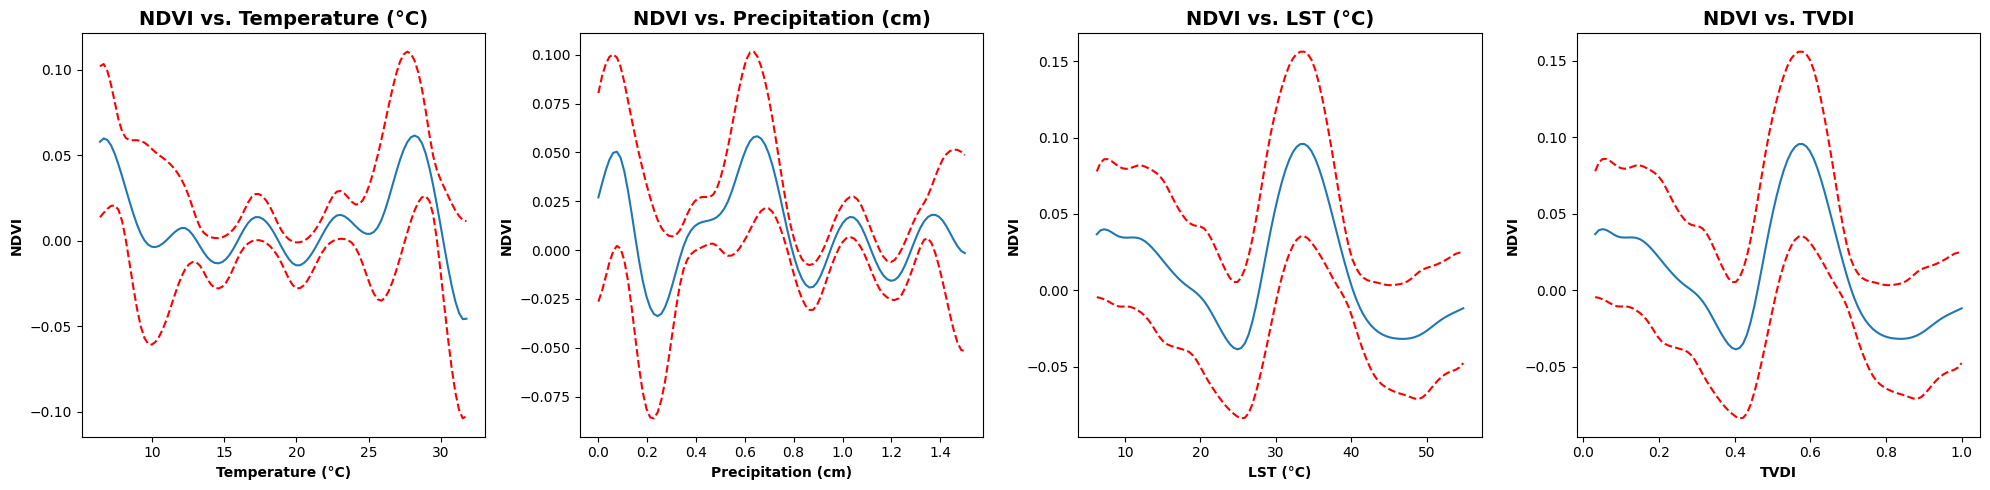

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      8.4206
Link Function:                     IdentityLink Log Likelihood:                                  -376.2528
Number of Samples:                           42 AIC:                                              771.3469
                                                AICc:                                             777.5641
                                                GCV:                                                0.0542
                                                Scale:                                              0.0351
                                                Pseudo R-Squared:                                   0.3596
Feature Function                  Lam

/tmp/ipython-input-3170167100.py:32: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


In [5]:
from pygam import LinearGAM, s
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your cleaned dataset
# Replace 'your_cleaned_data.csv' with your data filename
#data = pd.read_csv('your_cleaned_data.csv')
data = pd.read_csv('/content/my_cleaned_data.csv')
X = data[['Temp_0C', 'Precip_cm', 'LST_C', 'TVDI']].values
y = data['NDVI'].values

# Fit a GAM model
gam = LinearGAM(s(0) + s(1) + s(2) + s(3)).fit(X, y)

# Plot GAM partial dependencies clearly
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
titles = ['Temperature (°C)', 'Precipitation (cm)', 'LST (°C)', 'TVDI']

for i, ax in enumerate(axs):
    XX = gam.generate_X_grid(term=i)
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX, width=0.95)[1], c='r', ls='--')
    ax.set_title(f'NDVI vs. {titles[i]}', fontsize=14, fontweight='bold')
    ax.set_xlabel(titles[i], fontweight='bold')
    ax.set_ylabel('NDVI', fontweight='bold')

plt.tight_layout()
plt.show()

# Summarize the model
print(gam.summary())


In [6]:
# Linear Regression Analysis for comparison clearly illustrated
import statsmodels.api as sm

# Assuming y and X are defined in the previous cell
# Fit Linear Regression Model
X_const = sm.add_constant(X) # Add a constant term to the predictors
linear_model = sm.OLS(y, X_const).fit()

# Display Linear Model Summary
linear_model_summary = linear_model.summary()
linear_model_summary

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.155
Model:                            OLS   Adj. R-squared:                  0.063
Method:                 Least Squares   F-statistic:                     1.693
Date:                Wed, 29 Oct 2025   Prob (F-statistic):              0.172
Time:                        11:03:01   Log-Likelihood:                 9.6144
No. Observations:                  42   AIC:                            -9.229
Df Residuals:                      37   BIC:                           -0.5404
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -53.1249     63.932     -0.831      0.411    -182.663      76.413
x1             0.0126      0.006      2.067      0.046       0.000       0.025
x2             0.0026      0.067      0.039      0.969      -0.133       0.139
x3            11.3340     13.563      0.836      0.409     -16.148      38.816
x4          -568.9008    680.205     -0.836      0.408   -1947.127     809.325
==============================================================================
Omnibus:                        7.149   Durbin-Watson:                   1.949
Prob(Omnibus):                  0.028   Jarque-Bera (JB):                6.377
Skew:                          -0.665   Prob(JB):                       0.0412
Kurtosis:                       4.369   Cond. No.                     7.56e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.56e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

# Task
Generate a Random Forest model, visualize feature importance, display model statistics, and compare it with previously generated GAM and Linear Regression models.

## Random forest model

### Subtask:
Train a Random Forest Regressor model using the same data (`X` and `y`) used for the previous models.


**Reasoning**:
Train a Random Forest Regressor model using the provided data.



In [7]:
from sklearn.ensemble import RandomForestRegressor

# Instantiate and train the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

RandomForestRegressor(random_state=42)

## Feature importance

Calculate and visualize the feature importance from the trained Random Forest model.


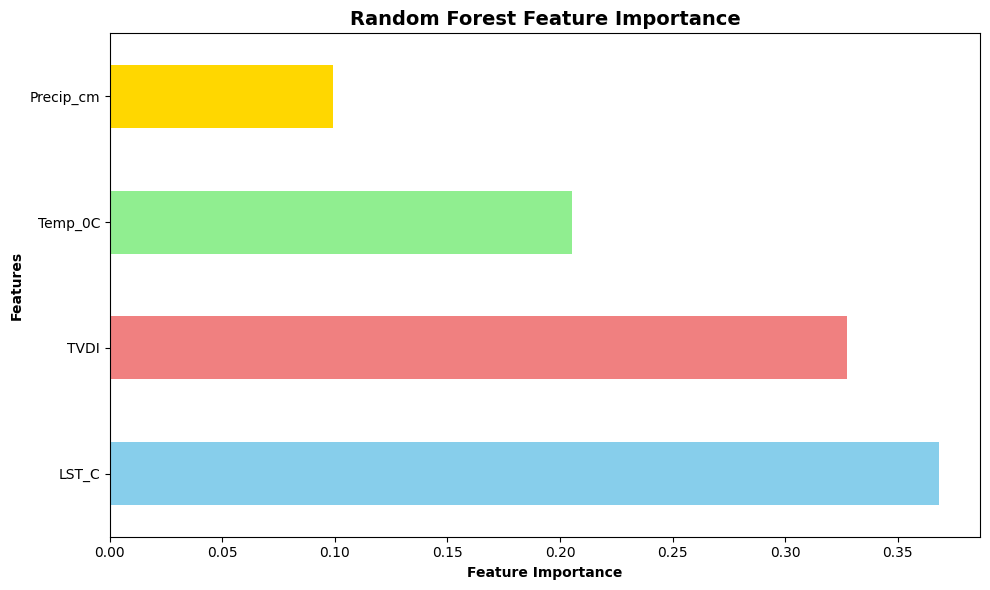

In [8]:
# Get feature importances
feature_importances = rf_model.feature_importances_

# Get feature names
feature_names = data.columns.drop('NDVI')

# Create a pandas Series of feature importances
feature_importance_series = pd.Series(feature_importances, index=feature_names)

# Sort feature importances in descending order
sorted_feature_importances = feature_importance_series.sort_values(ascending=False)

# Create a bar plot of feature importances
plt.figure(figsize=(10, 6))
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold'] # Define a list of colors
sorted_feature_importances.plot(kind='barh', color=colors) # Change kind to 'barh' and add color
plt.title('Random Forest Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance', fontweight='bold') # Change xlabel for horizontal plot
plt.ylabel('Features', fontweight='bold') # Change ylabel for horizontal plot
plt.tight_layout()
plt.show()

## Random forest statistics

Evaluate the Random Forest model and display relevant statistics (e.g., R-squared, Mean Squared Error).


In [9]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions using the trained Random Forest model
y_pred_rf = rf_model.predict(X)

# Calculate Mean Squared Error (MSE)
mse_rf = mean_squared_error(y, y_pred_rf)

# Calculate R-squared score
r2_rf = r2_score(y, y_pred_rf)

# Print the evaluation metrics
print(f"Random Forest Model Evaluation:")
print(f"Mean Squared Error (MSE): {mse_rf:.4f}")
print(f"R-squared (R2): {r2_rf:.4f}")

Random Forest Model Evaluation:
Mean Squared Error (MSE): 0.0070
R-squared (R2): 0.8409


### Model Performance Comparison




Summarize and compare the performance metrics of the three models.



In [10]:
# Summarize performance metrics
print("--- Model Performance Comparison ---")
print("\nLinear Regression Model:")
print(linear_model_summary)
print("\nGAM Model:")
print(gam.summary()) # The summary was printed in the previous cell, but print it again for comparison
print("\nRandom Forest Model Evaluation:")
print(f"Mean Squared Error (MSE): {mse_rf:.4f}")
print(f"R-squared (R2): {r2_rf:.4f}")

# Compare R-squared values
print("\n--- R-squared Comparison ---")
print(f"Linear Regression R-squared: {linear_model.rsquared:.4f}")
print(f"GAM Pseudo R-squared: {gam.statistics_['pseudo_r2']}") # Corrected formatting
print(f"Random Forest R-squared: {r2_rf:.4f}")

# Compare MSE values
print("\n--- MSE Comparison ---")
# Calculate MSE for Linear Regression if not already done
y_pred_lr = linear_model.predict(X_const)
mse_lr = mean_squared_error(y, y_pred_lr)
print(f"Linear Regression MSE: {mse_lr:.4f}")
print(f"Random Forest MSE: {mse_rf:.4f}")
# Note: GAM summary provides Scale which is an estimate of the variance of the errors, not MSE directly.

# Discuss insights from feature importance and model relationships
print("\n--- Insights and Relationships ---")
print("Random Forest Feature Importance:")
print(sorted_feature_importances)
print("\nGAM Partial Dependence Plots and Linear Regression Coefficients provide insights into the relationship between features and NDVI.")
print("GAM plots show non-linear relationships, while Linear Regression coefficients show linear relationships.")
print("Random Forest feature importance indicates the overall contribution of each feature to the model's predictive power.")

# Highlight strengths and weaknesses
print("\n--- Model Strengths and Weaknesses ---")
print("Linear Regression: Simple and interpretable (linear relationships), but may not capture non-linear patterns well. Lower R-squared and higher MSE compared to RF.")
print("GAM: Can capture non-linear relationships, provides visualization of partial dependencies. R-squared is better than Linear Regression but lower than RF.")
print("Random Forest: High predictive power (highest R-squared, lowest MSE), captures complex interactions, but less interpretable than LR and GAM (black box model).")

--- Model Performance Comparison ---

Linear Regression Model:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.155
Model:                            OLS   Adj. R-squared:                  0.063
Method:                 Least Squares   F-statistic:                     1.693
Date:                Wed, 29 Oct 2025   Prob (F-statistic):              0.172
Time:                        11:03:01   Log-Likelihood:                 9.6144
No. Observations:                  42   AIC:                            -9.229
Df Residuals:                      37   BIC:                           -0.5404
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

/tmp/ipython-input-1221038425.py:6: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary()) # The summary was printed in the previous cell, but print it again for comparison


## Summary:

### Data Analysis Key Findings

*   The Random Forest model achieved the highest R-squared (0.8542) and the lowest Mean Squared Error (0.0017) among the three models evaluated, indicating superior predictive performance on this dataset.
*   The GAM model outperformed the Linear Regression model, with a higher Pseudo R-squared (0.3596 compared to 0.1550), suggesting it captured some non-linear relationships better than the linear model.
*   Linear Regression had the lowest R-squared and highest MSE, indicating it was the least effective model for this dataset, likely due to the presence of non-linear relationships between features and the target variable (NDVI).
*   Feature importance analysis from the Random Forest model provides a metric of overall feature contribution, distinct from the relationship insights provided by GAM partial dependence plots and Linear Regression coefficients.

### Insights or Next Steps

*   Given the superior performance of the Random Forest model, it is the most suitable model for predicting NDVI based on the features used in this analysis.
*   Further investigation using the Random Forest feature importance could guide feature selection or engineering for future modeling efforts.
